# Air Temperature Time Series

## 1. Problem Statement

## 2. Domain Analysis

Surface air temperature is a crucial parameter in weather forecasting and climate monitoring. It is influenced by various factors, including geographic location, altitude, time of year, and atmospheric conditions. Understanding and predicting temperature changes can help mitigate risks associated with extreme weather events, optimize agricultural practices, and manage energy resources more efficiently.

## 3. Import Libraries

In [90]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

## 4. Loading Dataset

In [91]:
data = "surface-air-temperature-monthly-mean.csv"
data = pd.read_csv(data)

In [92]:
data.head()

,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0


In [93]:
# Convert the month column to datetime format and set it as index
data['month'] = pd.to_datetime(data['month'])
data.set_index('month', inplace = True)

In [94]:
data.sample(10)

,mean_temp
month,
2013-05-01,28.2
1999-07-01,27.8
2004-09-01,27.8
2020-03-01,28.6
1985-07-01,27.0
2009-12-01,27.1
2007-10-01,27.8
1988-05-01,28.4
1990-05-01,28.6


In [95]:
# Shape of data
data.shape

(462, 1)

In [96]:
# Get the information of data
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


## 5. Trend Visualization

### Visualization without seasonal trends

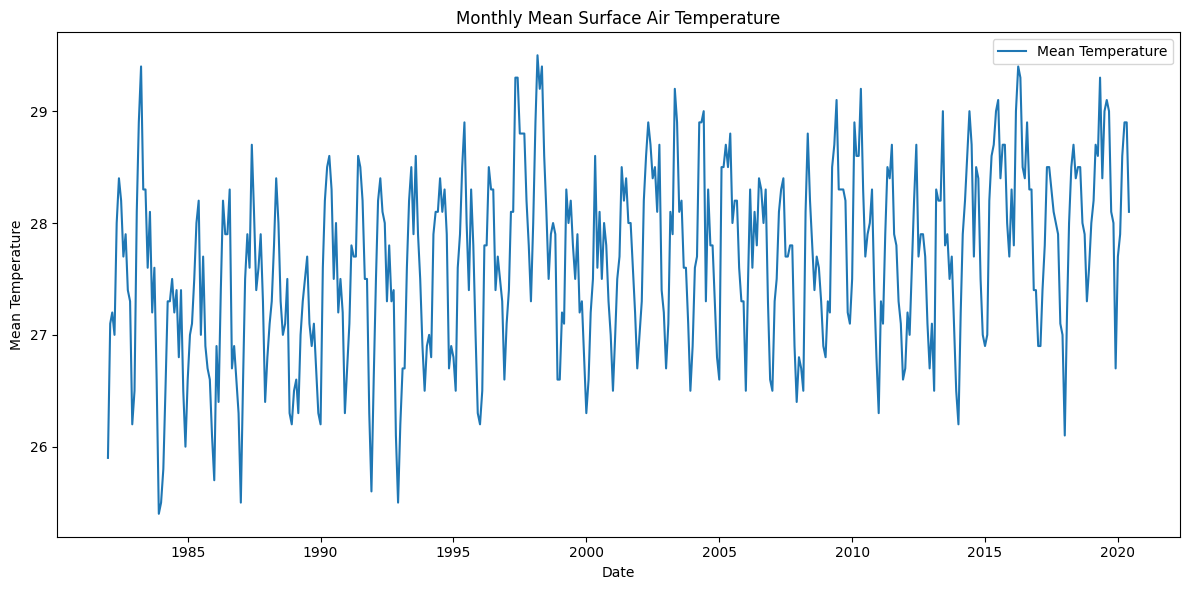

In [97]:
# Plot the time series to visualize trends and seasonality
plt.figure(figsize = (12,6))
plt.plot(data.index, data['mean_temp'], label = 'Mean Temperature')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title("Monthly Mean Surface Air Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### Visualization with seasonal trends

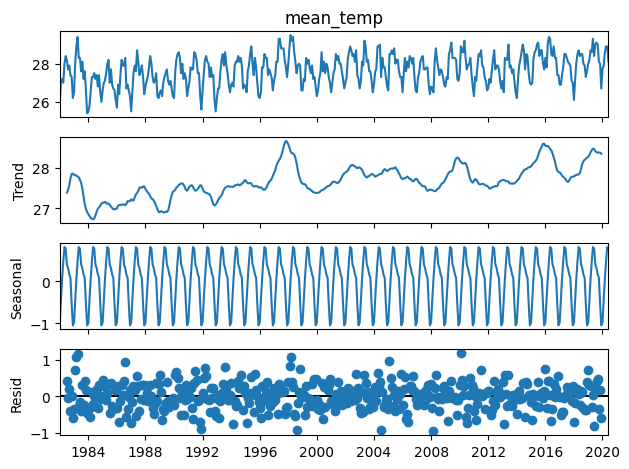

In [98]:
# Decompose the time series
decomposition = seasonal_decompose(data['mean_temp'], model = 'additive', period = 12)
decomposition.plot()
plt.tight_layout()
plt.show()

## 6. Model Fit

In [99]:
# Define and fit the SARIMA model
model_sarima = SARIMAX(data['mean_temp'],
                       order = (1, 1, 1),
                       seasonal_order = (1, 1, 1, 12),
                       enforce_stationarity = False,
                       enforce_invertibility = False)
sarima_fit = model_sarima.fit(disp = False)
print(sarima_fit.summary())

C:\Users\Dinesh H L\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dinesh H L\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          mean_temp   No. Observations:                  462
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -240.899
Date:                            Thu, 26 Mar 2026   AIC                            491.798
Time:                                    21:41:52   BIC                            512.174
Sample:                                01-01-1982   HQIC                           499.840
                                     - 06-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1984      0.064      3.124      0.002       0.074       0.323
ma.L1         -0.7924      0.042   

## 7. Data Preprocessing

In [100]:
# Prepare data for LSTM model
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[['mean_temp']])

In [101]:
# Convert data to supervised learning format
def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        a = data[i:(i + look_back), 0]
        X.append(a)
        Y.append(data[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12
X, Y = create_dataset(data_scaled, look_back)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [102]:
# Split data into train and test sets
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

## 8. Model Creation

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

# Define model
model_lstm = Sequential()

model_lstm.add(Input(shape=(look_back, 1)))

model_lstm.add(LSTM(400, return_sequences=True))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(200, return_sequences=True))  # FIXED
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(100, return_sequences=True))  # FIXED
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))  # LAST LSTM
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

# Compile
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model_lstm.fit(
    X_train, Y_train,
    epochs=1000,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0920 - val_loss: 0.0308
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0460 - val_loss: 0.0416
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0468 - val_loss: 0.0377
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0450 - val_loss: 0.0294
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0417 - val_loss: 0.0287
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0415 - val_loss: 0.0273
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0370 - val_loss: 0.0292
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0379 - val_loss: 0.0263
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0371 - val_loss: 0.0278
Epoch 10/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0360 - val_loss: 0.0283
Epoch 11/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0363 - val_loss: 0.0254
Epoch 12/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0

In [104]:
# Combine SARIMA and LSTM predictions
forecast_steps = 12

In [105]:
# SARIMA forecast
sarima_forecast = sarima_fit.get_forecast(steps=forecast_steps)
sarima_forecast_mean = sarima_forecast.predicted_mean

In [106]:
# LSTM forecast
last_data = data_scaled[-look_back:]
lstm_forecast = []
for _ in range(forecast_steps):
    lstm_input = last_data.reshape((1, look_back, 1))
    lstm_pred = model_lstm.predict(lstm_input)
    lstm_forecast.append(lstm_pred[0, 0])
    last_data = np.append(last_data[1:], lstm_pred)

lstm_forecast = scaler.inverse_transform(np.array(lstm_forecast).reshape(-1, 1)).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [107]:
# Combine forecasts by averaging
combined_forecast = (sarima_forecast_mean.values + lstm_forecast) / 2

## 9. Data Prediction visualization

C:\Users\Dinesh H L\AppData\Local\Temp\ipykernel_5068\2329317491.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='M')[1:]


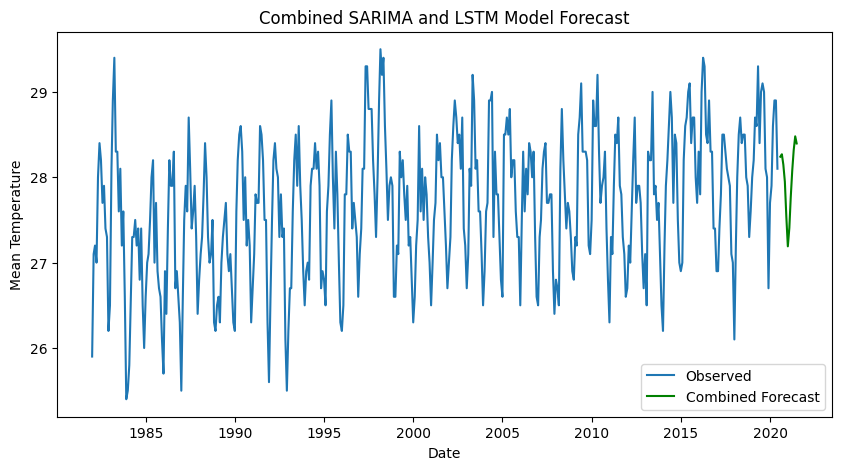

In [108]:
# Plot the combined forecast
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='M')[1:]
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['mean_temp'], label='Observed')
plt.plot(forecast_index, combined_forecast, label='Combined Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Combined SARIMA and LSTM Model Forecast')
plt.legend()
plt.show()

## 10. Model saving

In [109]:
# Save the models
sarima_fit.save('sarima_model.pkl')
model_lstm.save('lstm_model.h5')

import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## 11. Model Evaluation

In [110]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [111]:
# Evaluate SARIMA model on test data
sarima_test_forecast = sarima_fit.get_forecast(steps=len(Y_test))
sarima_test_mean = sarima_test_forecast.predicted_mean

In [112]:
# Evaluate LSTM model on test data
lstm_test_predictions = model_lstm.predict(X_test)
lstm_test_predictions = scaler.inverse_transform(lstm_test_predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


In [113]:
# Combine test predictions by averaging
combined_test_predictions = (sarima_test_mean.values + lstm_test_predictions.flatten()) / 2

In [114]:
# Calculate evaluation metrics
sarima_mse = mean_squared_error(Y_test, sarima_test_mean)
sarima_mae = mean_absolute_error(Y_test, sarima_test_mean)
sarima_rmse = np.sqrt(sarima_mse)

lstm_mse = mean_squared_error(Y_test, lstm_test_predictions)
lstm_mae = mean_absolute_error(Y_test, lstm_test_predictions)
lstm_rmse = np.sqrt(lstm_mse)

combined_mse = mean_squared_error(Y_test, combined_test_predictions)
combined_mae = mean_absolute_error(Y_test, combined_test_predictions)
combined_rmse = np.sqrt(combined_mse)

In [115]:
print(f"SARIMA Test MSE: {sarima_mse:.4f}, SARIMA Test MAE: {sarima_mae:.4f},SARIMA Test RMSE: {sarima_rmse:.4f}")
print(f"LSTM Test MSE: {lstm_mse:.4f}, LSTM Test MAE: {lstm_mae:.4f}, LSTM Test RMSE: {lstm_rmse:.4f}")
print(f"Combined Test MSE: {combined_mse:.4f}, Combined Test MAE: {combined_mae:.4f}, Combined Test RMSE: {combined_rmse:.4f}")

SARIMA Test MSE: 757.1075, SARIMA Test MAE: 27.5065,SARIMA Test RMSE: 27.5156
LSTM Test MSE: 733.5155, LSTM Test MAE: 27.0823, LSTM Test RMSE: 27.0835
Combined Test MSE: 745.0775, Combined Test MAE: 27.2944, Combined Test RMSE: 27.2961


## 12. Prediction test data

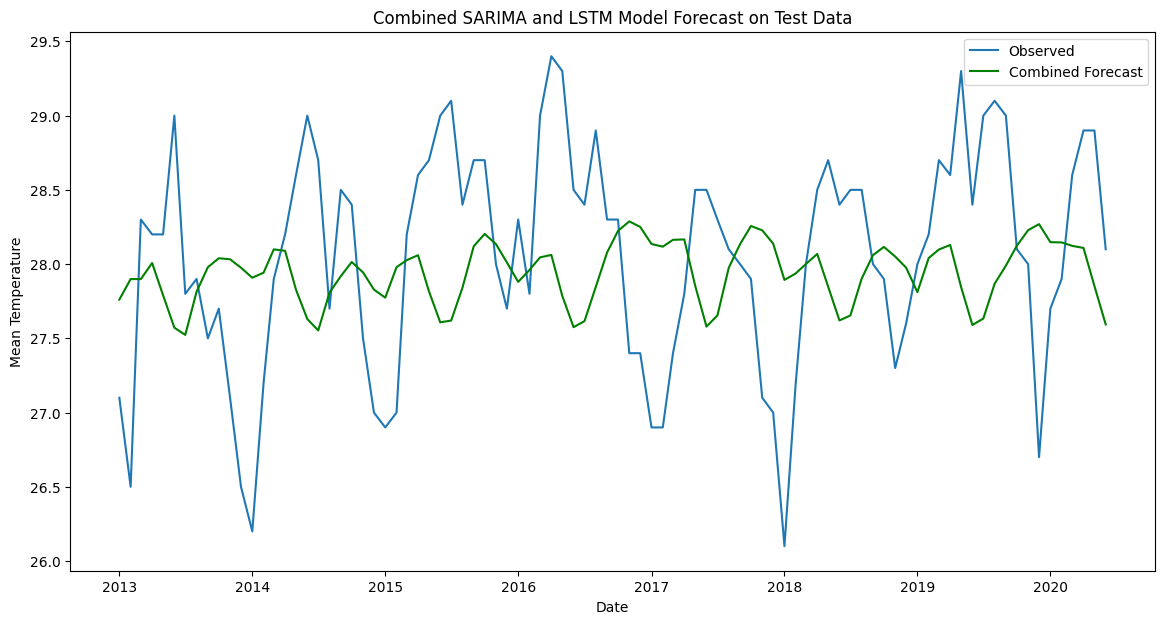

Baseline RMSE: 0.7428
Combined Model RMSE: 27.2961
The combined model does not perform better than the baseline model.


In [116]:
#Visualization and Comparison

# Plot observed vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(data.index[-test_size:], data['mean_temp'].values[-test_size:], label='Observed')
plt.plot(data.index[-test_size:], combined_test_predictions, label='Combined Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Combined SARIMA and LSTM Model Forecast on Test Data')
plt.legend()
plt.show()

# Calculate baseline model RMSE (e.g., using the mean value as prediction)
baseline_predictions = np.mean(data['mean_temp'].values[-test_size:])
baseline_rmse = np.sqrt(mean_squared_error(data['mean_temp'].values[-test_size:], [baseline_predictions] * test_size))

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Combined Model RMSE: {combined_rmse:.4f}")

if combined_rmse < baseline_rmse:
    print("The combined model performs better than the baseline model.")
else:
    print("The combined model does not perform better than the baseline model.")

## 13. Conclusion for time series using LSTM

## 14. Using the XGBoost model

In [117]:
# Import the libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

Repeating the data preprocessing steps 3,4,7 and continuing

In [118]:
# Reshape for XGBoost
X_train_reshaped = X_train.reshape(X_train.shape[0], look_back)
X_test_reshaped = X_test.reshape(X_test.shape[0], look_back)

In [119]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

# Hyperparameter tuning using Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train_reshaped, Y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='neg_mean_squared_error', verbose=1)

In [120]:
# Print the best parameters
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.9}


### Model training

In [121]:
# Train the XGBoost model with the best parameters
best_xgb_model = grid_search.best_estimator_
best_xgb_model.fit(X_train_reshaped, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

### Predictions

In [122]:
# Make predictions
train_predictions = best_xgb_model.predict(X_train_reshaped)
test_predictions = best_xgb_model.predict(X_test_reshaped)

### Model Evaluation

In [123]:
# Evaluation
train_rmse = np.sqrt(mean_squared_error(Y_train, train_predictions))
train_mae = mean_absolute_error(Y_train, train_predictions)
test_rmse = np.sqrt(mean_squared_error(Y_test, test_predictions))
test_mae = mean_absolute_error(Y_test, test_predictions)

print(f"Train RMSE: {train_rmse:.4f}, Train MAE: {train_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}")

Train RMSE: 0.0784, Train MAE: 0.0626
Test RMSE: 0.1160, Test MAE: 0.0934


### Visualization of predictions

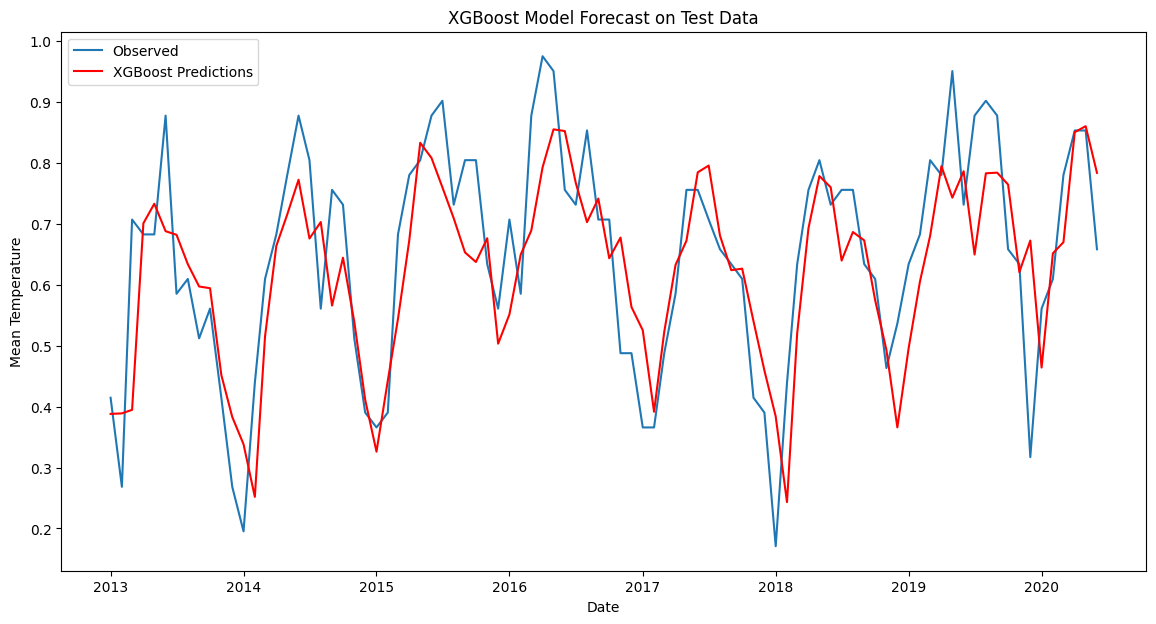

In [124]:
# Plot the predictions
plt.figure(figsize=(14, 7))
plt.plot(data.index[-test_size:], Y_test, label='Observed')
plt.plot(data.index[-test_size:], test_predictions, label='XGBoost Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('XGBoost Model Forecast on Test Data')
plt.legend()
plt.show()

# Save the model
best_xgb_model.save_model('xgboost_model.json')

In [125]:
# Calculate baseline model RMSE (e.g., using the mean value as prediction)
baseline_predictions = np.mean(data['mean_temp'].values[-test_size:])
baseline_rmse = np.sqrt(mean_squared_error(Y_test, [baseline_predictions] * test_size))

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"XGBoost Model RMSE: {test_rmse:.4f}")

if test_rmse < baseline_rmse:
    print("The XGBoost model performs better than the baseline model.")
else:
    print("The XGBoost model does not perform better than the baseline model.")

Baseline RMSE: 27.4085
XGBoost Model RMSE: 0.1160
The XGBoost model performs better than the baseline model.


## 15. Final Conclusion

XGBoost model’s RMSE is lower than the baseline RMSE, it indicates that the XGBoost model is effectively capturing the underlying patterns in the data and provides better predictions than the LSTM model and the Combined LSTM model.